# 1. Import library

In [1]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel, ExpSineSquared, DotProduct, ConstantKernel, RationalQuadratic
from sklearn.gaussian_process import GaussianProcessClassifier, GaussianProcessRegressor
from scipy.optimize import differential_evolution
from scipy.optimize import minimize
from scipy.stats import norm
from itertools import product
from skopt import gp_minimize
from skopt.space import Real

# 2. Data Inputs

In [2]:
inputs1 = np.array([[0.31940389, 0.76295937],
       [0.57432921, 0.8798981 ],
       [0.73102363, 0.73299988],
       [0.84035342, 0.26473161],
       [0.65011406, 0.68152635],
       [0.41043714, 0.1475543 ],
       [0.31269116, 0.07872278],
       [0.68341817, 0.86105746],
       [0.08250725, 0.40348751],
       [0.88388983, 0.58225397],
       [0.313131, 0.080808],
       [0.819461, 0.714329],
       [0.811000, 0.157249],
       [0.762763, 0.778779],
       [0.734909, 0.235836],
       [0.644645, 0.963964],
       [0.419419, 0.040040],
       [0.631544, 0.575192],
       [0.462488, 0.533511],
       [0.681227, 0.481494],
       [0.634909, 0.355339]])

# 3. Data Outputs

In [3]:
outputs1 = np.array([ 1.32267704e-079,  1.03307824e-046,  7.71087511e-016,
        3.34177101e-124, -3.60606264e-003, -2.15924904e-054,
       -2.08909327e-091,  2.53500115e-040,  3.60677119e-081,
        6.22985647e-048, -2.9364314294151675e-90, -1.4894966647291057e-31, 
        4.6334745434986095e-155, 7.361386681319969e-29,2.54080748409106e-93,
        4.606458583170689e-79,-7.228871076295598e-102,-0.01100062751124618, 2.047440710331553e-12,-1.0471006036307926e-17,
        1.1171153600383434e-35])

# 4. Data pre-processing

In [6]:
#Taking absolute values of the outputs as non-zero reading is required, i.e. it does not matter whetehr it is above / below zero
X = inputs1
y = np.abs(outputs1)

# 5. Visualization

## 5.1 Visualization of outputs trend

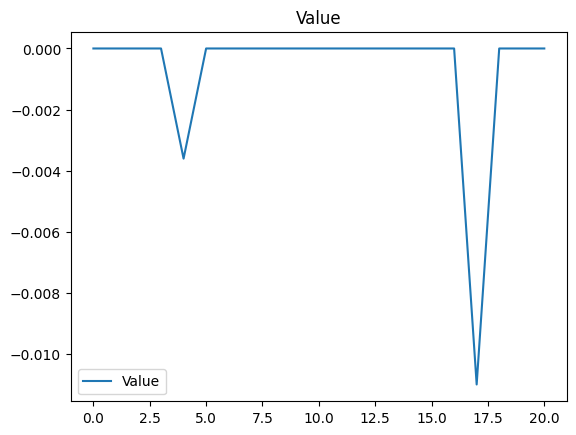

In [4]:
df = pd.DataFrame(outputs1, columns = ['Value'], index = range(outputs1.size))
plot = df.plot(title="Value")

## 5.2 Scatter plot - observations (2D)

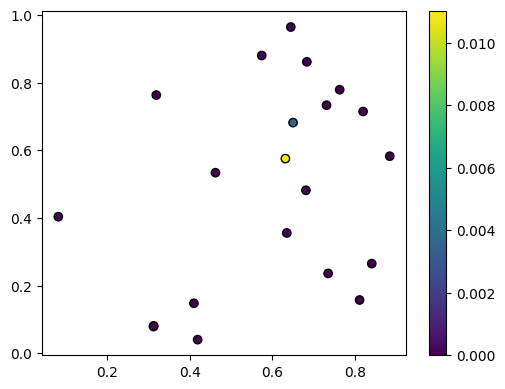

In [7]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", cmap="viridis")

plt.colorbar()

plt.tight_layout()
plt.show()

## 5.3 Scatter plot - observations (3D)

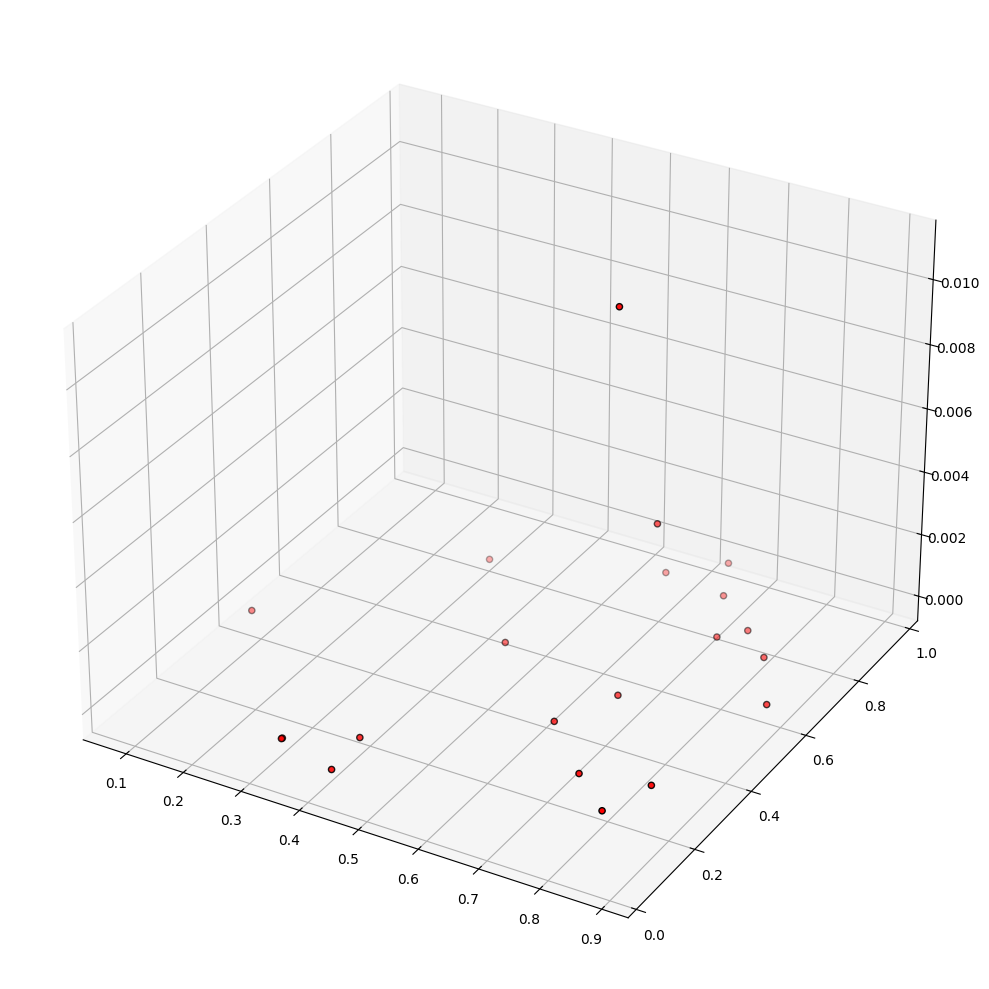

In [8]:
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], y, c = 'red', edgecolors="k")

plt.tight_layout()
plt.show()

# 6. Surrogate model

In [5]:
#Define kernel used
kernel_best_Q1_RBF = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=[0.05, 0.05], length_scale_bounds=(1e-2, 1e2))

#Initialize Gaussian Process Regressor
gp = GaussianProcessRegressor(kernel=kernel_best_Q1_RBF, n_restarts_optimizer=30, alpha=1e-6, normalize_y=True)

#Fit to data
gp.fit(X, y)

#Print the kernel to check if the value of optimized kernel is normal 
print("Optimized kernel:", gp.kernel_)

Optimized kernel: 0.971**2 * RBF(length_scale=[0.0248, 0.0865])


# 7. Acquisition function - UCB + Grid Search

In [12]:
#define UCB
def ucb(X_candidates, gp, kappa=2.0):
    mu, sigma = gp.predict(X_candidates, return_std=True)
    return mu + kappa * sigma

#Generate candidate points (dense grid in [0,1]^2)
x1 = np.linspace(0, 1, 4000)
x2 = np.linspace(0, 1, 4000)
X1, X2 = np.meshgrid(x1, x2)
X_grid = np.column_stack([X1.ravel(), X2.ravel()])

# Compute UCB
ucb_values = ucb(X_grid, gp, kappa=3)

# Pick next query point (max UCB)
next_point = X_grid[np.argmax(ucb_values)]
print("Next query point (by UCB):", next_point)

Next query point (by UCB): [0.61690423 0.59314829]
